In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from src.data_loader import DataLoader
from src.preprocessing import TimeSeriesPreprocessor
from src.portfolio import PortfolioOptimizer
from src.visualization import PortfolioVisualizer

In [2]:
assets = {

    "TSLA":"../data/processed/TSLA_processed.csv",

    "SPY":"../data/processed/SPY_processed.csv",

    "BND":"../data/processed/BND_processed.csv"

}

preprocessor = TimeSeriesPreprocessor()

returns = pd.DataFrame()

for asset, file in assets.items():

    loader = DataLoader(file)

    df = loader.load_data()

    df = preprocessor.clean_data(df)

    returns[asset] = df["Daily_Return"]

returns = returns.dropna()

returns.head()

,TSLA,SPY,BND
0,-0.042041,-0.018060,0.002904
1,-0.042041,-0.018060,0.002904
2,0.005664,-0.009419,0.002895
3,-0.001562,0.012461,0.000602
4,-0.001564,0.017745,-0.001563


In [3]:
forecast = pd.read_csv(
    "../outputs/TSLA_future_forecast.csv"
)

forecast.head()

,Date,Forecast,Lower_CI,Upper_CI
0,2026-06-30,375.73706,349.209283,402.264838
1,2026-07-01,375.89640,349.357366,402.435420
2,2026-07-02,371.58105,345.346699,397.815410
3,2026-07-03,365.52900,339.721924,391.336060
4,2026-07-06,358.99250,333.646914,384.338071


In [4]:
optimizer = PortfolioOptimizer(

    forecast_df=forecast,

    historical_returns=returns

)

In [6]:
expected_returns = optimizer.prepare_expected_returns()

expected_returns

TSLA   -0.450886
SPY     0.126126
BND    -0.008291
dtype: float64

In [7]:
covariance = optimizer.calculate_covariance()

covariance

,TSLA,SPY,BND
TSLA,0.326981,0.049849,0.001781
SPY,0.049849,0.031421,0.001040
BND,0.001781,0.001040,0.002883


In [8]:
optimizer.save_covariance(

    covariance,

    "../outputs/covariance_matrix.csv"

)

Saved covariance matrix:
..\outputs\covariance_matrix.csv


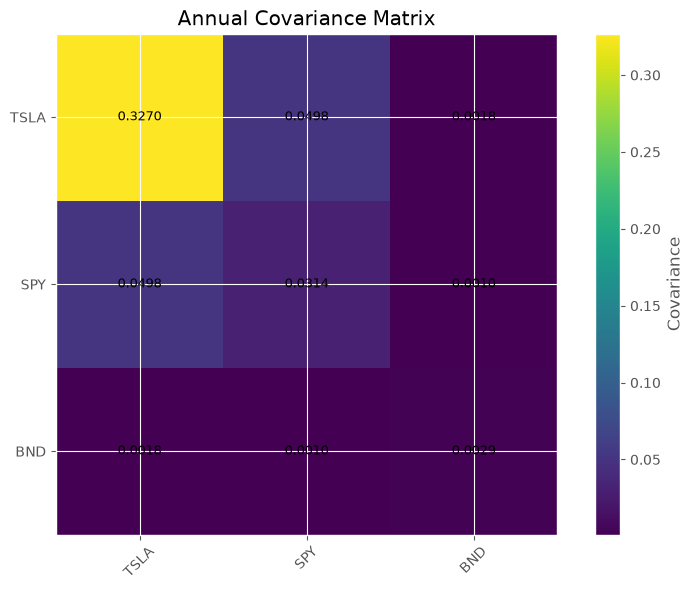

In [9]:
viz = PortfolioVisualizer()

viz.covariance_heatmap(

    covariance,

    "../figures/covariance_heatmap.png"

)

In [10]:
max_portfolio = optimizer.optimize_max_sharpe()

min_portfolio = optimizer.optimize_min_volatility()

print("Maximum Sharpe Portfolio")

print(max_portfolio)

print()

print("Minimum Volatility Portfolio")

print(min_portfolio)

Maximum Sharpe Portfolio
{'weights': OrderedDict([('TSLA', 0.0), ('SPY', 1.0), ('BND', 0.0)]), 'performance': {'Expected Return': np.float64(0.12612555435188003), 'Volatility': np.float64(0.1772590984466061), 'Sharpe Ratio': np.float64(0.5987030018876415)}}

Minimum Volatility Portfolio
{'weights': OrderedDict([('TSLA', 0.0), ('SPY', 0.05719), ('BND', 0.94281)]), 'performance': {'Expected Return': np.float64(-0.0006043479177355966), 'Volatility': np.float64(0.05270381353706827), 'Sharpe Ratio': np.float64(-0.011466872645003942)}}


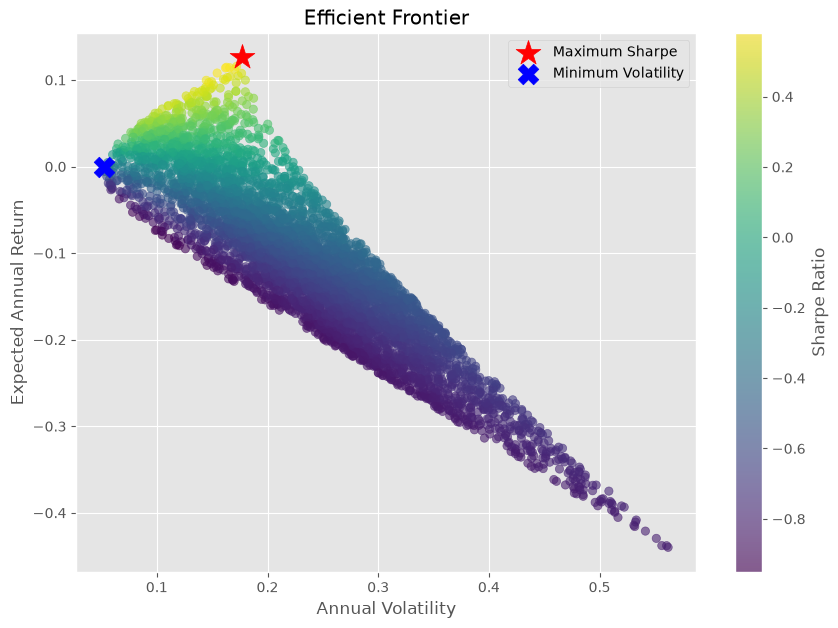

In [11]:
frontier = optimizer.generate_efficient_frontier(
    n_portfolios=5000
)

viz.efficient_frontier(

    frontier,

    max_portfolio,

    min_portfolio,

    "../figures/efficient_frontier.png"

)

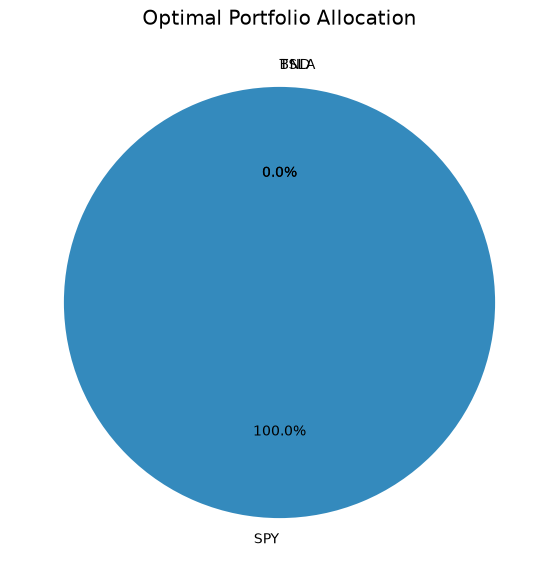

In [12]:
viz.portfolio_allocation(

    max_portfolio["weights"],

    "../figures/portfolio_allocation.png"

)

In [13]:
portfolio = optimizer.save_portfolio(

    max_portfolio["weights"],

    "../outputs/optimal_portfolio.csv"

)

summary = optimizer.summary_dataframe(

    max_portfolio,

    min_portfolio

)

optimizer.save_summary(

    summary,

    "../outputs/portfolio_summary.csv"

)

summary

Portfolio saved:
..\outputs\optimal_portfolio.csv
Summary saved:
..\outputs\portfolio_summary.csv


,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.126126,0.177259,0.598703
1,Minimum Volatility,-0.000604,0.052704,-0.011467


Optimal Portfolio Recommendation

Based on the Modern Portfolio Theory analysis, the **Maximum Sharpe Ratio Portfolio** has been selected as the optimal portfolio. This portfolio aims to maximize the risk-adjusted return, offering the highest expected return for each unit of risk taken. While the Minimum Volatility Portfolio provides the lowest risk, its negative expected return and Sharpe Ratio make it undesirable. The Maximum Sharpe Ratio Portfolio, consisting entirely of SPY with 100% allocation, demonstrates a positive expected annual return of approximately 12.61% and a Sharpe Ratio of 0.5987, indicating a favorable balance between reward and risk. The zero allocation to TSLA is likely due to its significantly negative forecasted expected return, making it an unfavorable asset to hold for maximizing risk-adjusted returns within this portfolio context. Similarly, BND also has a negative expected return, leading to no allocation in the Max Sharpe portfolio.